In [10]:
from config import NAVY, RED, GREY, BG

In [11]:
import pandas as pd
import numpy as np
import shap
import matplotlib.pyplot as plt
import pickle

# Load saved artifacts
with open('model_artifacts.pkl', 'rb') as f:
    artifacts = pickle.load(f)

lr = artifacts['lr_model']
xgb = artifacts['xgb_model']
scaler = artifacts['scaler']
X_test = artifacts['X_test']
y_test = artifacts['y_test']

print("Artifacts loaded ✅")
print(f"Test set: {X_test.shape}")

Artifacts loaded ✅
Test set: (200, 18)


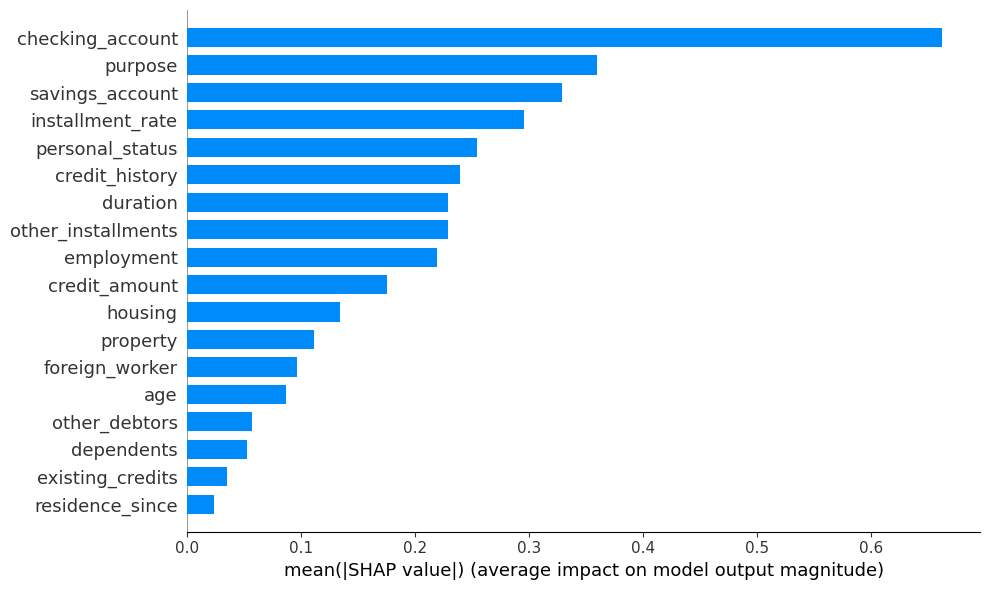

In [12]:
import shap

# SHAP for Logistic Regression
X_test_scaled = scaler.transform(X_test)
explainer_lr = shap.LinearExplainer(lr, scaler.transform(artifacts['X_train']))
shap_values_lr = explainer_lr.shap_values(X_test_scaled)

# Global feature importance
shap.summary_plot(shap_values_lr, X_test, plot_type='bar', 
                  show=True, plot_size=(10, 6))

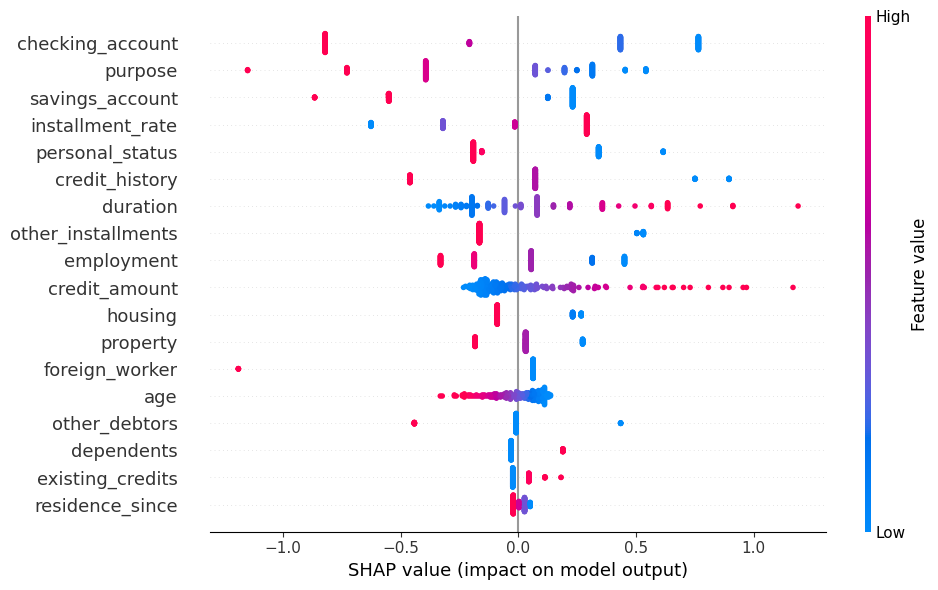

In [13]:
# SHAP summary plot - beeswarm 
shap.summary_plot(shap_values_lr, X_test, show=True, plot_size=(10, 6))

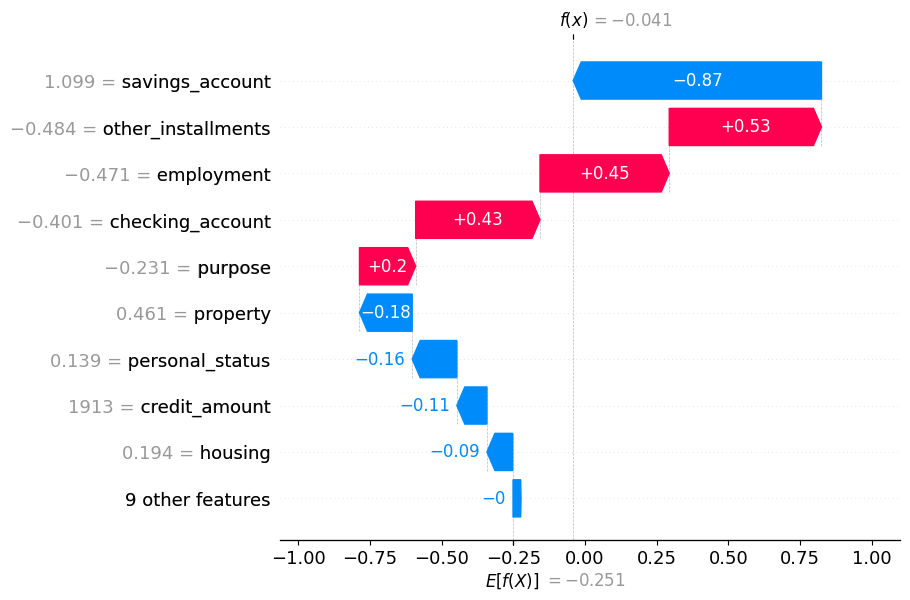

In [14]:
# Local explanation - single applicant
shap.waterfall_plot(shap.Explanation(
    values=shap_values_lr[0],
    base_values=explainer_lr.expected_value,
    data=X_test.iloc[0],
    feature_names=X_test.columns.tolist()
))